In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def hr_curve_1min(rr_s: pd.Series,
                 tz: str = "Asia/Shanghai",
                 min_beats: int = 20,
                 smooth_min: int | None = 3):
    rr = rr_s.copy()
    rr.index = pd.to_datetime(rr.index, unit="s", utc=True).tz_convert(tz)

    rr_1min_mean = rr.resample("1min").mean()
    nbeats_1min = rr.resample("1min").count()

    hr_1min = 60.0 / rr_1min_mean
    hr_1min[nbeats_1min < min_beats] = np.nan  # 质量门控：断开曲线

    if smooth_min is not None and smooth_min > 1:
        hr_plot = hr_1min.rolling(smooth_min, center=True, min_periods=1).mean()
    else:
        hr_plot = hr_1min

    out = pd.DataFrame({"hr_bpm": hr_1min, "hr_plot": hr_plot, "n_beats": nbeats_1min})
    return out

def plot_hr(out: pd.DataFrame, title: str = "Heart Rate (1-min)"):
    fig, ax = plt.subplots(figsize=(12, 4))
    x = out.index.tz_convert("Asia/Shanghai").tz_localize(None)
    ax.plot(x, out["hr_plot"].values)

    ax.set_title(title)
    ax.set_ylabel("HR (bpm)")
    ax.set_xlabel("Time")

    # 时间轴更像人类：每 5/10 分钟一个刻度，自动格式化
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=12))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_quality(out: pd.DataFrame, title: str = "Beats per minute (quality proxy)"):
    fig, ax = plt.subplots(figsize=(12, 2.5))
    ax.plot(out.index, out["n_beats"].values)

    ax.set_title(title)
    ax.set_ylabel("n_beats")
    ax.set_xlabel("Time")

    loc = mdates.AutoDateLocator(minticks=6, maxticks=12, tz=out.index.tz)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    ax.grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_hr_with_markers_maxN(out, max_markers=120, title="HR curve (1-min)"):
    x = out.index.tz_localize(None) if getattr(out.index, "tz", None) is not None else out.index
    y = out["hr_plot"].values

    n = len(out)
    step = max(1, n // max_markers)  # 自动算间隔
    idx = np.arange(0, n, step)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x, y, linewidth=1.5, color='lightseagreen', label='Heart rate')
    ax.plot(x[idx], y[idx], linestyle="None", marker="o", markersize=3, color='orange')

    ax.set_title(title)
    ax.set_ylabel("HR (bpm)")
    ax.set_xlabel("Time")

    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=12))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig, ax

2026-02-21 00:20:58 – 2026-02-21 05:28:33  |  05:07:34
Samples: 4505771  |  fs: 250.00 Hz  |  Beats: 19122
Mean HR: 64 bpm  |  SDNN: 120 ms  |  RMSSD: 72 ms


<Axes: >

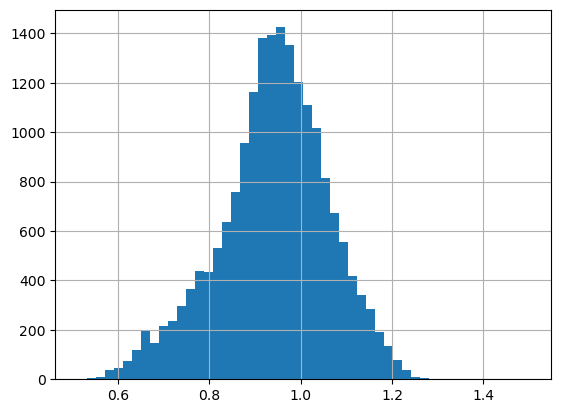

In [ ]:
from ecg_core.rr_hr_hrv import *
ecg = pd.read_parquet('ecg_log_2026-02-21_002056.parquet')
#ecg['time'] -= ecg['time'].values[0]
ecg_t0 = ecg['time'].values[0]
ecg = ecg[ecg['time'] < ecg_t0+18455]
ecg = ecg[ecg['lead'] == 0]

ecg_beats = BeatCalc(ecg)
print(ecg_beats.ecg_info())
pd.Series(ecg_beats.rr_clean).hist(bins=50)

## 心率画图（1 min一次）

In [4]:
t_rr = ecg_beats.r_series[1:]
rr = pd.Series(ecg_beats.rr_intervals, index=t_rr, dtype=float)
rr.index = (
    pd.to_datetime(rr.index, unit="s", utc=True)
      .tz_convert("Asia/Shanghai")
)
hr_1min = 60.0 / rr.resample("1min").mean()   # NaN自动跳过

# 可选：顺便给每分钟统计一下有效心跳数（用于质量控制）
nbeats_1min = rr.resample("1min").count()

# 你可以把它们合并成一个表
out = pd.DataFrame({"hr_bpm": hr_1min, "n_beats": nbeats_1min})

C:\Users\79205\AppData\Local\Temp\ipykernel_9548\1756932746.py:79: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.tight_layout()
C:\Users\79205\AppData\Local\Temp\ipykernel_9548\470128255.py:11: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.savefig("HR_min_plot.jpg", dpi=300)
C:\Users\79205\AppData\Local\Temp\ipykernel_9548\470128255.py:11: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.savefig("HR_min_plot.jpg", dpi=300)
d:\Softwares\Miniconda\envs\ecg_env\lib\site-packages\IPython\core\pylabtools.py:170: U

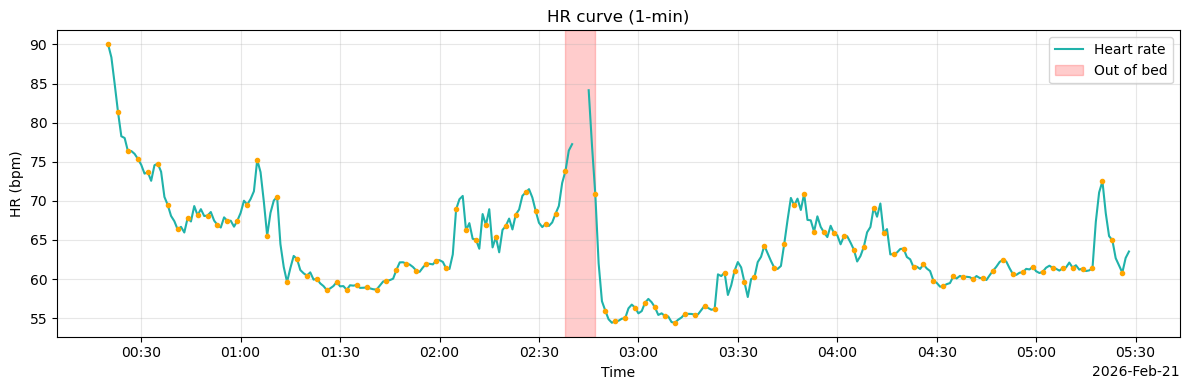

In [5]:
out = hr_curve_1min(rr, min_beats=20, smooth_min=3)
#plot_hr(out, title="HR curve (1-min, gated + smoothed)")
#plot_quality(out)
fig, ax = plot_hr_with_markers_maxN(out, max_markers=80)
subset = out.loc["2026-02-21 02:38":"2026-02-21 02:46"]
start = pd.Timestamp("2026-02-21 02:38")
end = pd.Timestamp("2026-02-21 02:47")
ax.axvspan(start, end, color='red', alpha=0.2, label="Out of bed")
#ax.axvspan(1, 3, color='red', alpha=0.3, label='Zone A')
ax.legend()
plt.savefig("HR_min_plot.jpg", dpi=300)